## The effect of Stellar Temperature on Luminosity of Stars

This code is used to generate the results for the paper. 

### Load libraries

In [12]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects.packages import importr
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import random
import importlib
import generativeAI
importlib.reload(generativeAI)
from generativeAI import *
import kagglehub
from kagglehub import KaggleDatasetAdapter


## Estimate the effect of Stellar Temperature on Luminosity of Stars using Generative AI and GRF. 

In [13]:

# Create results directory if it doesn't exist
results_dir = 'results'
if not os.path.exists(results_dir):
    os.makedirs(results_dir)

# Set all seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set R seed
ro.r('set.seed')(SEED)

def load_and_split_star_data(test_size=0.5, random_state=SEED):
    """
    Load and preprocess stars dataset
    Features include:
    - Temperature (K)
    - Luminosity (L/Lo)
    - Radius (R/Ro)
    - Absolute magnitude (Mv)
    - Star color
    """
    # Load from local CSV file
    data = pd.read_csv('Stars.csv')
    
    print("Dataset loaded successfully")
    print("Raw data shape:", data.shape)
    print("Available columns:", data.columns.tolist())
    
    # Separate numerical and categorical features
    numerical_features = ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)']
    X_numerical = data[numerical_features]
    
    # Create binary treatment based on temperature
    temperature_median = data['Temperature (K)'].median()
    D = (data['Temperature (K)'] > temperature_median).astype(int)
    
    # Outcome: Luminosity
    Y = data['Luminosity (L/Lo)']
    
    # Split data
    X_train, X_test, D_train, D_test, Y_train, Y_test = train_test_split(
        X_numerical, D, Y, test_size=test_size, random_state=random_state, stratify=D
    )
    
    # Standardize numerical variables
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    print("\nDataset Summary:")
    print(f"Training samples: {len(X_train)}")
    print(f"Test samples: {len(X_test)}")
    print(f"Features: {numerical_features}")
    print(f"Training treatment proportion: {D_train.mean():.3f}")
    print(f"Test treatment proportion: {D_test.mean():.3f}")
    print("\nTreatment definition:")
    print(f"Stars with temperature > {temperature_median:.2f}K are treated (hot stars)")
    print(f"Outcome: Luminosity (L/Lo)")
    
    return X_train, D_train, Y_train, X_test, D_test, Y_test



# Import R's GRF package
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
base = importr('base')
grf = importr('grf')
# Load and split data
X_train, D_train, Y_train, X_test, D_test, Y_test = load_and_split_star_data()

# Convert to R and run GRF (numpy2ri enables numpy array -> R conversion)
with localconverter(ro.default_converter + numpy2ri.converter):
    # Convert training data to R format
    X_train_r = ro.r.matrix(X_train, nrow=X_train.shape[0], ncol=X_train.shape[1])
    D_train_r = ro.FloatVector(D_train)
    Y_train_r = ro.FloatVector(Y_train)

    # Convert test data to R format
    X_test_r = ro.r.matrix(X_test, nrow=X_test.shape[0], ncol=X_test.shape[1])
    D_test_r = ro.FloatVector(D_test)
    Y_test_r = ro.FloatVector(Y_test)

    # Train GRF
    print("\nTraining GRF model...")
    cf = grf.causal_forest(X_train_r, Y_train_r, D_train_r, seed=SEED)

    # Get predictions on test set (handle both R object and numpy recarray from converter)
    pred_grf = grf.predict_causal_forest(cf, X_test_r)
    tau_grf_test = np.array(pred_grf.rx2('predictions') if hasattr(pred_grf, 'rx2') else pred_grf['predictions'])

# Initialize and train GenerativeTE model
print("\nTraining GenerativeTE model...")
model = TreatmentEffectNet(x_dim=X_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
n_epochs = 100
batch_size = 32
n_samples = len(X_train)


for epoch in range(n_epochs):
    # Convert to numpy arrays for shuffling
    X_train_array = np.array(X_train)
    D_train_array = np.array(D_train)
    Y_train_array = np.array(Y_train)
    
    # Shuffle training data
    idx = np.random.permutation(n_samples)
    X_shuffle = X_train_array[idx]
    D_shuffle = D_train_array[idx]
    Y_shuffle = Y_train_array[idx]
    
    # Mini-batch training
    for i in range(0, n_samples, batch_size):
        batch_X = torch.FloatTensor(X_shuffle[i:i+batch_size])
        batch_D = torch.FloatTensor(D_shuffle[i:i+batch_size])
        batch_Y = torch.FloatTensor(Y_shuffle[i:i+batch_size])
        
        optimizer.zero_grad()
        loss = model.loss_fn(batch_X, batch_Y, batch_D, [1.0, 0.1, 0.1])
        loss.backward()
        optimizer.step()

# Get GenerativeTE predictions on test set
tau_gen_test = []
for i in range(len(X_test)):
    with torch.no_grad():
        x = torch.FloatTensor(X_test[i:i+1])
        z = torch.ones(1)
        tau = np.random.uniform(0.01, 0.99)  # avoid exact 0/1
        _, _, te, _ = model(x, z, tau)
        tau_gen_test.append(te.numpy()[0, 0])
tau_gen_test = np.array(tau_gen_test)

# Print results
print("\nTest Set Results:")
print("GRF:")
print(f"Average Treatment Effect: {np.mean(tau_grf_test):.2f}")
print(f"Standard Deviation: {np.std(tau_grf_test):.2f}")

print("\nGenerativeTE:")
print(f"Average Treatment Effect: {np.mean(tau_gen_test):.2f}")
print(f"Standard Deviation: {np.std(tau_gen_test):.2f}")

# Set style for better PDF output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Create single density plot
plt.figure(figsize=(6, 5))

# Distribution plot with filled densities
sns.kdeplot(tau_grf_test, label='GeneralizedRF', color='#967BB6', fill=True, alpha=0.8)
sns.kdeplot(tau_gen_test, label='GenerativeTE', color='#4C787E', fill=True, alpha=0.8)
plt.title('Distribution of Treatment Effects')
plt.xlabel('The effect of high temperature on luminosity of stars')
plt.ylabel('Density')
plt.legend()

plt.tight_layout()

# Save only the density plot in results directory
plt.savefig(os.path.join(results_dir, 'star_comparison_test_set.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'star_comparison_test_set.png'), dpi=300, bbox_inches='tight')
plt.close()

# Save results to DataFrame
results_df = pd.DataFrame({
    'Statistic': ['Average Treatment Effect', 'Standard Deviation'],
    'GenerativeTE': [np.mean(tau_gen_test), np.std(tau_gen_test)],
    'GRF': [np.mean(tau_grf_test), np.std(tau_grf_test)]
})

# Save to LaTeX in results directory
latex_table = results_df.to_latex(index=False, float_format="%.2f")
with open(os.path.join(results_dir, 'star_results.tex'), 'w') as f:
    f.write(latex_table)

print("\nResults have been saved in the 'results' directory:")
print("1. 'star_comparison_test_set.pdf' (Plots)")
print("2. 'star_comparison_test_set.png' (Plots)")
print("3. 'star_results.tex' (LaTeX table)")

Dataset loaded successfully
Raw data shape: (240, 8)
Available columns: ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)', 'Star type', 'Star category', 'Star color', 'Spectral Class']

Dataset Summary:
Training samples: 120
Test samples: 120
Features: ['Temperature (K)', 'Luminosity (L/Lo)', 'Radius (R/Ro)', 'Absolute magnitude (Mv)']
Training treatment proportion: 0.500
Test treatment proportion: 0.500

Treatment definition:
Stars with temperature > 5776.00K are treated (hot stars)
Outcome: Luminosity (L/Lo)

Training GRF model...

Training GenerativeTE model...

Test Set Results:
GRF:
Average Treatment Effect: -32204.53
Standard Deviation: 21641.33

GenerativeTE:
Average Treatment Effect: 4056.59
Standard Deviation: 7532.96

Results have been saved in the 'results' directory:
1. 'star_comparison_test_set.pdf' (Plots)
2. 'star_comparison_test_set.png' (Plots)
3. 'star_results.tex' (LaTeX table)


## Simulation Study

Run GenerativeTE and GRF on simulated data with known treatment effects. The DGP is:
- **Covariates:** \(X \sim N(0, I)\)
- **Baseline:** \(\mu(X) = X\beta_\mu\)
- **Treatment effect:** \(\theta(X) = 1 + X_1 + 0.5 X_2\) (heterogeneous)
- **Treatment:** Observational (propensity depends on X) or RCT (random)
- **Outcome:** \(Y = \mu(X) + \theta(X) D + \varepsilon\)

Simulation: n=500, 4 features, observational treatment
True ATE (test): 0.9879
GRF ATE:          1.0244, MSE vs true: 0.3378
GenerativeTE ATE: 1.1308, MSE vs true: 0.0794


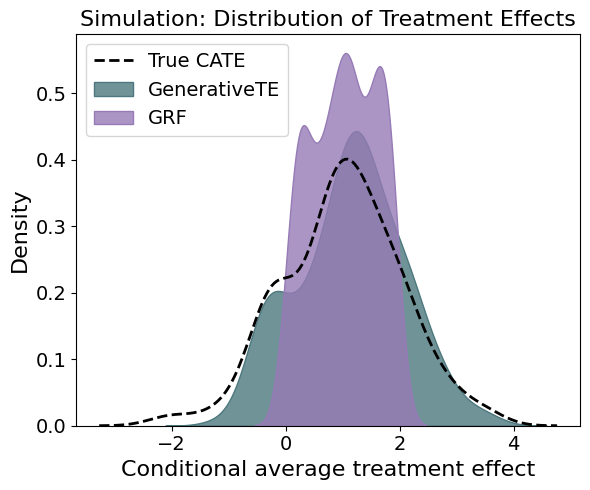

In [14]:
def simulate_causal_data(n_samples=500, n_features=4, treatment_type='observational', random_state=SEED):
    """Simulate Y = mu(X) + theta(X)*D + epsilon with known CATE."""
    rng = np.random.default_rng(random_state)
    X = rng.standard_normal((n_samples, n_features))
    beta_mu = rng.standard_normal(n_features) * 0.5
    mu = X @ beta_mu
    theta_true = 1.0 + X[:, 0] + 0.5 * X[:, 1]
    if treatment_type == 'rct':
        D = rng.binomial(1, 0.5, n_samples)
    else:
        logit = 0.3 * X[:, 0] - 0.2 * X[:, 1] + 0.1 * X[:, 2]
        p = 1 / (1 + np.exp(-logit))
        D = rng.binomial(1, p, n_samples)
    Y = mu + theta_true * D + rng.standard_normal(n_samples) * 0.5
    return X, D, Y, theta_true

# Generate and split simulated data
X, D, Y, tau_true = simulate_causal_data(n_samples=500, n_features=4, treatment_type='observational')
X_train, X_test, D_train, D_test, Y_train, Y_test, tau_train, tau_test = train_test_split(
    X, D, Y, tau_true, test_size=0.5, random_state=SEED, stratify=D
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Simulation: n=500, 4 features, observational treatment")
print(f"True ATE (test): {tau_test.mean():.4f}")

# GRF
with localconverter(ro.default_converter + numpy2ri.converter):
    X_train_r = ro.r.matrix(X_train, nrow=X_train.shape[0], ncol=X_train.shape[1])
    D_train_r = ro.FloatVector(D_train)
    Y_train_r = ro.FloatVector(Y_train)
    X_test_r = ro.r.matrix(X_test, nrow=X_test.shape[0], ncol=X_test.shape[1])
    cf_sim = grf.causal_forest(X_train_r, Y_train_r, D_train_r, seed=SEED)
    pred_grf_sim = grf.predict_causal_forest(cf_sim, X_test_r)
    tau_grf_sim = np.array(pred_grf_sim.rx2('predictions') if hasattr(pred_grf_sim, 'rx2') else pred_grf_sim['predictions'])

# GenerativeTE
model_sim = TreatmentEffectNet(x_dim=X_train.shape[1])
optimizer_sim = optim.Adam(model_sim.parameters(), lr=0.001)
for epoch in range(100):
    idx = np.random.permutation(len(X_train))
    for i in range(0, len(X_train), 32):
        batch_X = torch.FloatTensor(X_train[idx[i:i+32]])
        batch_D = torch.FloatTensor(D_train[idx[i:i+32]])
        batch_Y = torch.FloatTensor(Y_train[idx[i:i+32]])
        optimizer_sim.zero_grad()
        model_sim.loss_fn(batch_X, batch_Y, batch_D, [1.0, 0.1, 0.1]).backward()
        optimizer_sim.step()

tau_gen_sim = []
with torch.no_grad():
    for i in range(len(X_test)):
        _, _, te, _ = model_sim(torch.FloatTensor(X_test[i:i+1]), torch.ones(1), 0.5)
        tau_gen_sim.append(te.numpy()[0, 0])
tau_gen_sim = np.array(tau_gen_sim)

print(f"GRF ATE:          {tau_grf_sim.mean():.4f}, MSE vs true: {np.mean((tau_grf_sim - tau_test)**2):.4f}")
print(f"GenerativeTE ATE: {tau_gen_sim.mean():.4f}, MSE vs true: {np.mean((tau_gen_sim - tau_test)**2):.4f}")

# Plot
plt.figure(figsize=(6, 5))
sns.kdeplot(tau_test, label='True CATE', color='black', linestyle='--', linewidth=2)
sns.kdeplot(tau_gen_sim, label='GenerativeTE', color='#4C787E', fill=True, alpha=0.8)
sns.kdeplot(tau_grf_sim, label='GRF', color='#967BB6', fill=True, alpha=0.8)
plt.title('Simulation: Distribution of Treatment Effects')
plt.xlabel('Conditional average treatment effect')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'simulation_comparison.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'simulation_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

## Density plot for the effect of Stellar Temperature on Luminosity of Stars (Generative AI)

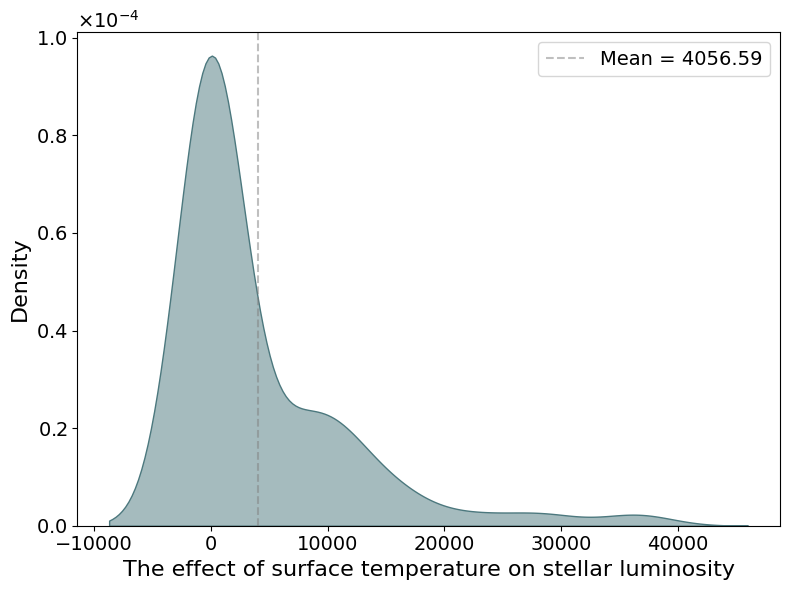

In [15]:
# Set style for better PDF output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Increase only axis-related font sizes
plt.rcParams['axes.labelsize'] = 16  # Increased axis label size
plt.rcParams['xtick.labelsize'] = 14  # Increased tick label size
plt.rcParams['ytick.labelsize'] = 14  # Increased tick label size
plt.rcParams['legend.fontsize'] = 14  # Increased legend size

# Calculate mean of treatment effects
mean_effect = np.mean(tau_gen_test)


# Create density plot
plt.figure(figsize=(8, 6))
sns.kdeplot(data=tau_gen_test, 
            color='#4C787E',
            fill=True,
            alpha=0.5,
            label='')

# Format y-axis to use scientific notation
plt.gca().yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


plt.xlabel('The effect of surface temperature on stellar luminosity')
plt.ylabel('Density')
plt.title('')
plt.axvline(x=mean_effect, color='gray', linestyle='--', alpha=0.5, label=f'Mean = {mean_effect:.2f}')
plt.legend()
plt.tight_layout()

# Save plots
plt.savefig(os.path.join(results_dir, 'treatment_effects_density.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'treatment_effects_density.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Density plot for the effect of Stellar Temperature on Luminosity of Stars (GRF)

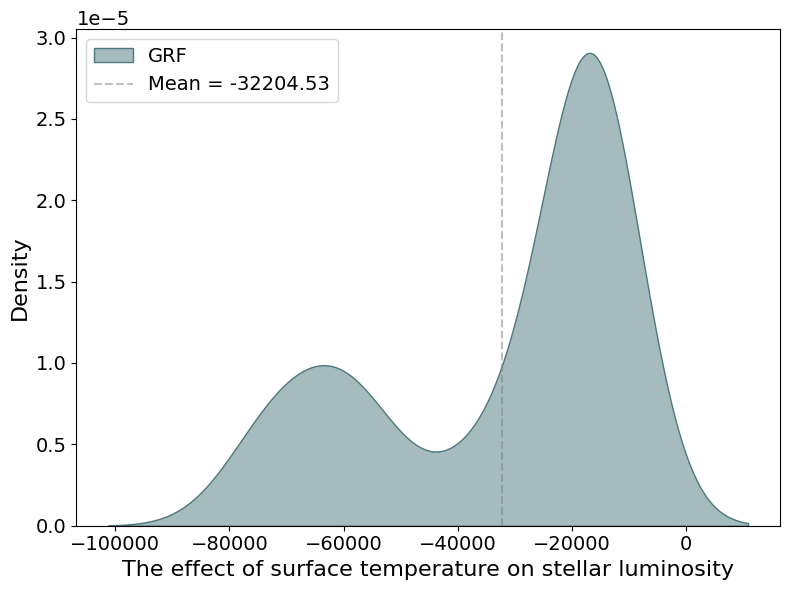

In [16]:
## Such a plot for GRF 
# Set style for better PDF output
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
# Increase only axis-related font sizes
plt.rcParams['axes.labelsize'] = 16  # Increased axis label size
plt.rcParams['xtick.labelsize'] = 14  # Increased tick label size
plt.rcParams['ytick.labelsize'] = 14  # Increased tick label size
plt.rcParams['legend.fontsize'] = 14  # Increased legend size


# Calculate mean of GRF treatment effects
mean_effect_grf = np.mean(tau_grf_test)

# Create density plot
plt.figure(figsize=(8, 6))
sns.kdeplot(data=tau_grf_test, 
            color='#4C787E',
            fill=True,
            alpha=0.5,
            label='GRF')

plt.xlabel('The effect of surface temperature on stellar luminosity')
plt.ylabel('Density')
plt.title('')
plt.axvline(x=mean_effect_grf, color='gray', linestyle='--', alpha=0.5, label=f'Mean = {mean_effect_grf:.2f}')
plt.legend()
plt.tight_layout()

# Save plots
plt.savefig(os.path.join(results_dir, 'treatment_effects_density_grf.pdf'), dpi=300, bbox_inches='tight')
plt.savefig(os.path.join(results_dir, 'treatment_effects_density_grf.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()